# Lab 6: Examining the Therapeutic Touch

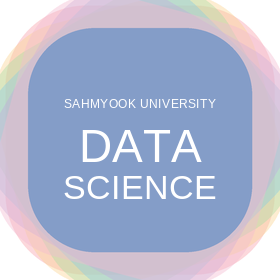

Welcome to Lab 6! This assignment involves using statistical modeling, hypothesis testing, and simulation to analyze data and draw conclusions

**Recommended Reading**:

* [Assessing a Model](https://inferentialthinking.com/chapters/11/1/Assessing_a_Model.html)
* [Empirical Distribution of a Statistic](https://inferentialthinking.com/chapters/10/3/Empirical_Distribution_of_a_Statistic.html)
* [Random Sampling in Python](https://inferentialthinking.com/chapters/10/4/Random_Sampling_in_Python.html)
* [Python Reference](https://www.data8.org/sp26/reference/)


In [ ]:
# Setup (run this first!)
!pip install -q otter-grader datascience
!git clone https://github.com/jihyungkim94/datascience.git 2>/dev/null || true
import os, json
os.chdir('/content/datascience/lab/lab06')
os.makedirs('tests', exist_ok=True)
with open('lab06.ipynb') as _f:
    _nb = json.load(_f)
for _name, _test in _nb['metadata']['otter']['tests'].items():
    with open('tests/' + _name + '.py', 'w') as _f:
        _f.write('OK_FORMAT = True\n\ntest = ' + repr(_test) + '\n')
import otter
grader = otter.Notebook('lab06.ipynb')
print('Ready! (8 tests loaded)')

**Submission**: When you're finished, run every cell and check that the tests pass, then download the notebook with **File → Download → Download .ipynb** and upload it to the LMS.

Let's begin by setting up the tests and imports by running the cell below.

After such an extensive introduction to programming for data science, we are finally moving into the section of the course where we can apply our new skills to answer real questions.  

In this lab, we'll use testing techniques that were introduced in lecture to test the idea of the therapeutic touch, the idea that some practitioner can feel and massage your human energy field. 


In [ ]:
# Run this cell, but please don't change it.
 
# These lines import the Numpy and Datascience modules.
import numpy as np
from datascience import *
def sample_proportions(sample_size, probabilities):
    return np.random.multinomial(sample_size, probabilities) / sample_size

# These lines do some fancy plotting magic
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import warnings
warnings.simplefilter('ignore', FutureWarning)
from matplotlib import patches
from ipywidgets import interact, interactive, fixed
import ipywidgets as widgets

<hr style="border: 5px solid #4a6591;" />
<hr style="border: 1px solid #7a98c7;" />

## 1. What is the Therapeutic Touch

The Therapeutic Touch (TT) is the idea that everyone can feel the Human Energy Field (HEF) around individuals.  Those who practice TT have described different people's HEFs as "warm as Jell-O" and "tactile as taffy." 

TT was a popular technique used throughout the 20th century that was touted as a great way to bring balance to a person's health. Certain practitioners claim they have the ability to feel the HEF and can massage it in order to promote health and relaxation in individuals.

### Emily Rosa

[Emily Rosa](https://en.wikipedia.org/wiki/Emily_Rosa) was a 4th grade student who was very familiar with the world of TT, thanks to her parents, who were both medical practitioners and skeptics of TT.

For her 4th grade science fair project, Emily decided to test whether or not TT practitioners could truly interact with a person's HEF. She later went on to publish her work in TT, becoming the youngest person to have a research paper published in a peer reviewed medical journal.

### Emily's Experiment

Emily's experiment was clean, simple, and effective. Due to her parents' occupations in the medical field, she had wide access to people who claimed to be TT practitioners. 

Emily recruited 21 Therapeutic Touch (TT) practitioners to participate in her science experiment. She would take a TT practitioner and ask them to extend their hands through a screen (which they can't see through). Emily would be on the other side and would flip a fair coin. Depending on how the coin landed, she would put out either her left hand or her right hand. The TT practitioner would then have to answer which hand Emily put out. If a practitioner could truly interact with a person's HEF, it would be expected that they answered correctly.

Overall, through 210 samples, the practitioner picked the correct hand 44% of the time. 

Emily's main goal here was to test whether or not the TT practitioners' guesses were random, like the flip of a coin. In most medical experiments, this is the norm. **We want to test whether or not the treatment has an effect, *not* whether or not the treatment actually works.**

We will now begin to formulate this experiment in terms of the terminology we learned in this course. 

<!-- BEGIN QUESTION -->

---

**Question 1.1**: Describe Emily’s [model](https://inferentialthinking.com/chapters/11/1/Assessing_a_Model.html) for how likely the TT practitioners are to choose the correct hand. What alternative model is her model meant to discredit?

If you are able, check in with fellow peers, the discussion forum, or your lab TA/tutors, to come to a conclusion.


_Type your answer here, replacing this text._

<!-- END QUESTION -->

--- 

**Question 1.2:** Remember that the practitioner got the correct answer 44% (0.44) of the time. According to Emily's model, on average, what proportion of times do we expect the practitioner to guess the correct hand? Make sure your answer is a number between 0 and 1. 


In [ ]:
expected_proportion_correct = ...
expected_proportion_correct

In [ ]:
grader.check("q1_2")

The goal now is to see if our deviation from this expected proportion of correct answers is due to something other than chance. 

--- 

**Question 1.3:** We usually use a statistic to help determine which model the evidence points towards. What is a statistic that we can use to compare outcomes under Emily’s model to what was observed? Assign `valid_stat` to an array of integer(s) representing test statistics that Emily can use: 

1. The difference between the expected percent correct and the actual percent correct
2. The absolute difference between the expected percent correct and the actual percent correct
3. The sum of the expected percent correct and the actual percent correct

**NOTE:** Make sure to use `make_array` to create your array of integer(s)!

> *Hint*: What should the domain (possible x values) be for the distribution of our test statistics?


In [ ]:
valid_stat = ...
valid_stat

In [ ]:
grader.check("q1_3")

<!-- BEGIN QUESTION -->

--- 

**Question 1.4:** Why is the statistic from Question 1.3 the appropriate choice for comparing outcomes in Emily's experiment? How does it relate to the models you defined in Question 1.1? 

If you are able, check in with fellow peers, the discussion forum, or your lab TA/Tutors.


_Type your answer here, replacing this text._

<!-- END QUESTION -->

--- 

**Question 1.5:** Define the function `statistic` which takes in an expected proportion and an actual proportion, and returns the value of the statistic chosen in Question 1.3. Assume that the argument takes in proportions, but  return your answer as a percentage. 

*Hint:* Remember we are asking for a **percentage**, not a proportion. 


In [ ]:
def statistic(expected_prop, actual_prop):
    ...

In [ ]:
grader.check("q1_5")

--- 

**Question 1.6:** Use your newly defined function to calculate the observed statistic from Emily's experiment. 


In [ ]:
observed_statistic = ...
observed_statistic

In [ ]:
grader.check("q1_6")

**Is this observed statistic consistent with what we expect to see under Emily’s model?**

In order to answer this question, we must simulate the experiment as though Emily's model was correct, and calculate our statistic for every simulation.

### `sample_proportions`

`sample_proportions` can be used to randomly sample from multiple categories when you know the proportion of data points that are expected to fall in each category. `sample_proportions` takes two arguments: the sample size and an array of proportions corresponding to each category in the population (should sum to 1).

Consider flipping a fair coin, where the two outcomes (coin lands heads and coin lands tails) occur with an equal chance. We expect that half of all coin flips will land heads, and half of all coin flips will land tails.

Run the following cell to see the simulation of 10 flips of a fair coin. Let the first item of `coin_proportions` be the proportion of heads and the second item of `coin_proportions` be the proportion of tails.

*Observe what happens when you run this cell multiple times—the proportion of coin flips that land heads and tails appears to change, as you are simulating flipping 10 coins each time!*

In [ ]:
coin_proportions = make_array(0.5, 0.5) 
ten_flips = sample_proportions(10, coin_proportions)
ten_flips

`sample_proportions` returns an array that is the same length as the proportion array that is passed through. It contains the proportion of each category that appears in the sample. 

In our example, the first item of `ten_flips` is the simulated proportion of heads and the second item of `ten_flips` is the simulated proportion of tails.

In [ ]:
simulated_proportion_heads = ten_flips.item(0)
simulated_proportion_tails = ten_flips.item(1)

print("In our simulation, " + str(simulated_proportion_heads) + " of flips were heads and " \
      + str(simulated_proportion_tails) + " of flips were tails.")

---

**Question 1.7:** To begin simulating, we should start by creating a representation of Emily's model to use for our simulation. This will be an array with two items in it. The first item should be the proportion of times a TT practitioner picks the correct hand, assuming that Emily’s model was correct. The second item should be the proportion of times, under the same assumption, that the TT practitioner picks the incorrect hand. Assign `model_proportions` to this array. 

After this, we can simulate 210 hand choices, as Emily evaluated in real life, and find a single statistic to summarize this instance of the simulation. Use the `sample_proportions` function and **assign the simulated proportion of correct hand choices to** `simulation_proportion_correct`. Lastly, use your `statistic` function to assign `one_statistic`  to the value of the statistic for this one simulation.

*Hint:* `sample_proportions` usage can be found on the [Python Reference](https://www.data8.org/sp26/reference/).

*Note:* Once you are done, you can observe how `one_statistic` randomly changes by commenting out `np.random.seed(16)`. Just make sure to uncomment it before running the grader check.

In [ ]:
# This saves the random state of our code so that we can 
# generate the same numbers each time we run the code.
# Please do not change this line. 
np.random.seed(16)

model_proportions = ...
simulation_proportion_correct = ...
one_statistic = ...
one_statistic

In [ ]:
grader.check("q1_7")

---

**Question 1.8:** Let's now see what the distribution of statistics is actually like under Emily's model. 

Define the function `simulation_and_statistic` to take in the `model_proportions` array and the expected proportion of times a TT practitioner would guess a hand correctly under Emily's model. The function should simulate Emily running through the experiment 210 times and return the statistic of this one simulation.

*Hint:* This should follow the same pattern as the code you did in the previous problem.  

In [ ]:
def simulation_and_statistic(model_proportions, expected_proportion_correct):
    '''Simulates 210 TT hand choices under Emily’s model. 
    Returns one statistic from the simulation.'''
    ...

Using this function, assign `simulated_statistics` to an array of 1000 statistics that you calculated under the assumption that Emily's model was true.

In [ ]:
num_repetitions = 1000

simulated_statistics = ...

for ... in ...:
    ...

In [ ]:
grader.check("q1_8")

Let's view the distribution of the simulated statistics under Emily's model, and visually compare where the observed statistic lies relative to the simulated statistics.

In [ ]:
t = Table().with_column('Simulated Statistics', simulated_statistics)
t.hist()
plt.scatter(observed_statistic, 0, color='red', s=100, zorder=2);

We can make a visual argument as to whether we believe the observed statistic is consistent with Emily’s model. Here, since larger values of the test statistic suggest the alternative model (where the chance of guessing the correct hand is something other than 50%), we can formalize our analysis by finding what proportion of simulated statistics were as large or larger than our observed test statistic (the area at or to the right of the observed test statistic). If this area is small enough, we’ll declare that the observed data are inconsistent with our simulated model. Here is the [in the textbook's model assessment section](https://inferentialthinking.com/chapters/11/1/Assessing_a_Model.html#comparing-the-prediction-and-the-data) to the section in the textbook.

--- 

**Question 1.9:** Calculate the proportion of simulated statistics in Question 1.8 greater than or equal to the observed statistic. 

*Hint:* `np.count_nonzero` usage can be found [in the textbook's randomness chapter](https://inferentialthinking.com/chapters/09/Randomness.html).


In [ ]:
proportion_greater_or_equal = ...
proportion_greater_or_equal

In [ ]:
grader.check("q1_9")

By convention, we often compare the proportion we just calculated to 0.05. If the proportion of simulated statistics greater than or equal to the observed statistic is sufficiently small (less than or equal to 0.05), then this is evidence **against** Emily's model. Conceptually, you may think of this as the case where less than 5% of simulated values are as far or farther away from what we had expected. This would mean that seeing a result **as extreme as our observed value** would be very **unlikely** under Emily’s model, given how rarely that occurred in our simulations.

This should help you make your own conclusions about Emily Rosa's experiment. 

Therapeutic touch fell out of use after this experiment, which was eventually accepted into one of the premier medical journals. TT practitioners hit back and accused Emily and her family of tampering with the results, while some claimed that Emily's bad spiritual mood towards therapeutic touch made it difficult to read her HEF. Whatever it may be, Emily's experiment is a classic example about how anyone, with the right resources, can test anything they want!

---

**Question 1.10:** Now, take some time to reflect on the questions below and then, discuss with your peers or take a look at the discussions on the Ed post for this lab.

1. Is the data more consistent with Emily' model (practitioners were randomly guessing)?
2. What does this mean in terms of Emily's experiment? Do the TT practitioners' answers follow an even chance model or is there something else at play? 

Did you talk to your peers or look at the discussion forum? (True/False)


In [ ]:
peer_talk = ...
peer_talk

In [ ]:
grader.check("q1_10")

## Pets of this data science course

Barley, Summer, Kiwi hope you had fun doing this lab!

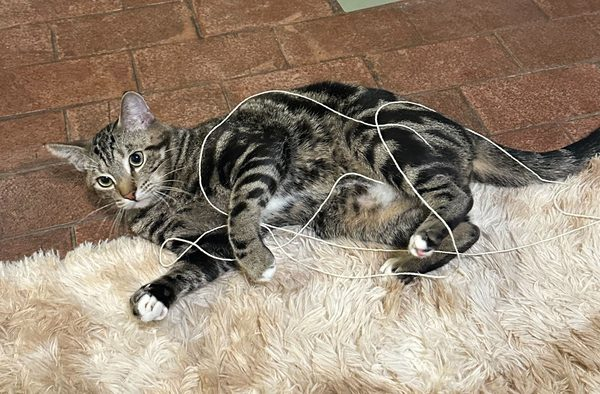
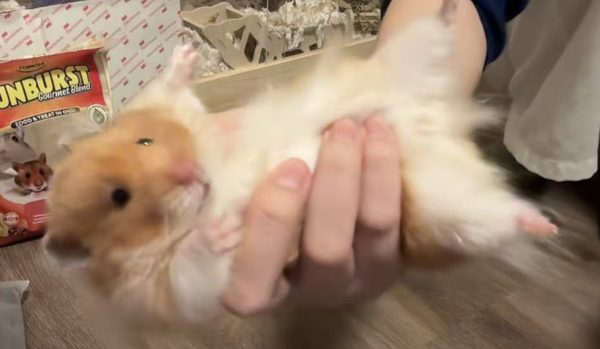
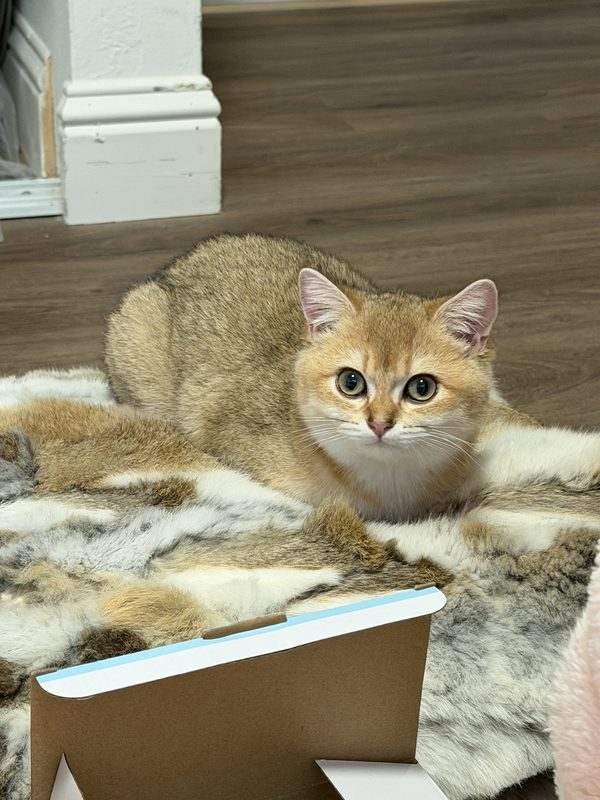

Congrats on completing Lab 6!


---

You're done with lab!

**Important submission steps:**
1. Run all the cells and verify that every test passes.
2. Choose **File → Download → Download .ipynb**.
3. Upload the `.ipynb` file to the LMS.

**Make sure every cell has been run before you download — the outputs are part of what you hand in.**


---

To double-check your work, the cell below will rerun all of the autograder tests.

In [ ]:
grader.check_all()

### Submission
1. Run `grader.check_all()` above and make sure all tests pass.
2. **File → Download → Download .ipynb**
3. Upload the `.ipynb` file to the LMS.

_(`grader.export()` does not work on Google Colab, so it has been removed.)_